# Category Intelligence – Retail Product Performance EDA

## Calibo AI Academy – Phase 1 Mini Use Case 01

### Project Objective

This project analyzes six months of retail sales data from January to June 2026.

The objective is to identify:

- Growing and declining product categories
- Top and bottom performing products
- Discount effectiveness
- Day-of-week and monthly sales patterns
- Business recommendations for the Category Manager

## CBIM Problem Canvas

### Situation
A regional retail chain operates 12 stores across Andhra Pradesh and sells products across five categories. The Category Manager is preparing for a supplier review meeting.

### Complication
The Category Manager needs to understand which categories and products are performing well and which are declining.

### Question
Which product categories are growing or declining, which products are driving performance, and what should the Category Manager prioritize or deprioritize?

### SSOT
The single source of truth is the `MUC01_Retail_Sales_Dataset.csv` transaction dataset.

### Success Definition
The analysis should provide clear charts, tables and business insights that can support supplier-review decisions.

### Primary Stakeholder
The primary stakeholder is the Category Manager.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [39]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

print(df.head())

  transaction_id        date store_id  store_city     category product_name  \
0      TXN000001  2026-01-01      S01  Vijayawada  Electronics     Smart TV   
1      TXN000002  2026-01-01      S01  Vijayawada  Electronics       Laptop   
2      TXN000003  2026-01-01      S01  Vijayawada  Electronics       Tablet   
3      TXN000004  2026-01-01      S01  Vijayawada  Electronics     Smart TV   
4      TXN000005  2026-01-01      S01  Vijayawada      Apparel        Jeans   

   units_sold  unit_price   revenue  discount_pct  
0           2     3075.46   5843.37             5  
1           1    11598.06  11598.06             0  
2           3     5738.37  15493.60            10  
3           3     3281.28   9351.65             5  
4           1     1917.14   1917.14             0  


In [40]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (107836, 10)

Column Names:
['transaction_id', 'date', 'store_id', 'store_city', 'category', 'product_name', 'units_sold', 'unit_price', 'revenue', 'discount_pct']

Data Types:
transaction_id        str
date                  str
store_id              str
store_city            str
category              str
product_name          str
units_sold          int64
unit_price        float64
revenue           float64
discount_pct        int64
dtype: object

Missing Values:
transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64


In [41]:
print("Number of Products:", df["product_name"].nunique())
print("Number of Categories:", df["category"].nunique())

print("\nCategories:")
print(df["category"].unique())

Number of Products: 25
Number of Categories: 5

Categories:
<StringArray>
['Electronics', 'Apparel', 'Grocery', 'Home & Kitchen', 'Personal Care']
Length: 5, dtype: str


In [42]:
df.describe()

,units_sold,unit_price,revenue,discount_pct
count,107836.000000,107836.000000,107836.000000,107836.000000
mean,2.583488,1778.097787,4263.920924,7.228152
std,1.471616,5053.631792,14243.244169,6.730445
min,1.000000,50.020000,40.040000,0.000000
25%,1.000000,274.827500,467.772500,0.000000
50%,2.000000,488.450000,1034.615000,5.000000
75%,3.000000,1039.522500,2473.335000,10.000000
max,13.000000,44990.140000,355090.880000,20.000000


## Step 2 – Category Revenue Trend

We analyze monthly revenue for each product category from January to June 2026.

This helps the Category Manager identify which categories are growing, declining, or remaining relatively stable.

In [43]:
df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.to_period("M").astype(str)

print(df[["date", "month"]].head())

        date    month
0 2026-01-01  2026-01
1 2026-01-01  2026-01
2 2026-01-01  2026-01
3 2026-01-01  2026-01
4 2026-01-01  2026-01


In [44]:
category_month = df.groupby(
    ["month", "category"]
)["revenue"].sum().unstack()

print(category_month)

category      Apparel  Electronics     Grocery  Home & Kitchen  Personal Care
month                                                                        
2026-01   10049916.78  45686596.63  7307011.34     15130871.54     6593734.81
2026-02    9510938.10  38988602.50  6534957.35     13006413.31     5792754.97
2026-03   11540439.47  40846509.47  7132787.06     14362119.50     6808029.34
2026-04   11681806.66  37092265.09  7047399.58     13431147.66     6417868.13
2026-05   13219535.79  34226926.43  7232706.20     13581886.25     7298818.71
2026-06   13476952.88  29686824.81  7047719.23     12333283.07     6737354.12


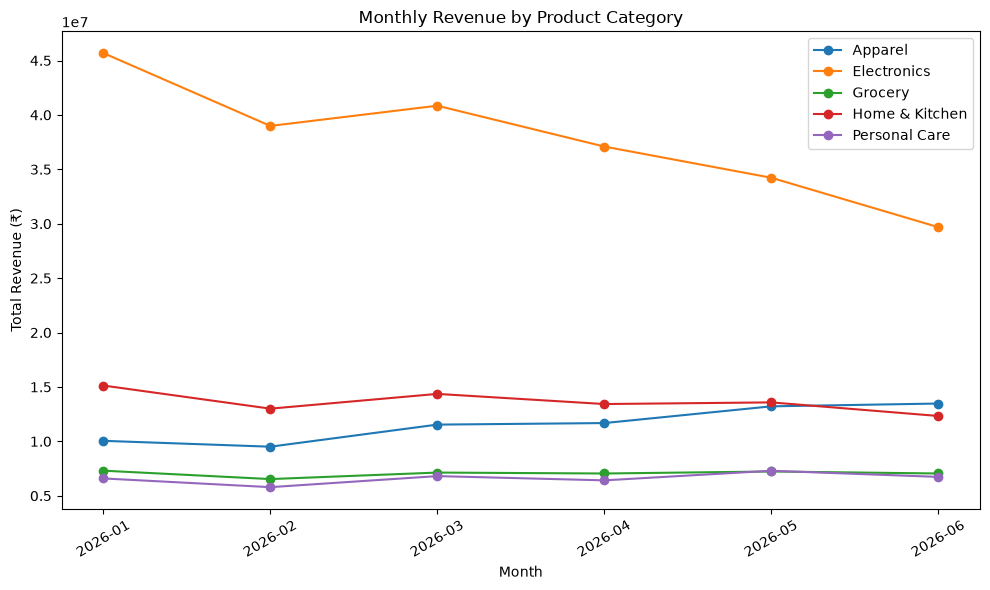

In [45]:
plt.figure(figsize=(10, 6))

for category in category_month.columns:
    plt.plot(
        category_month.index,
        category_month[category],
        marker="o",
        label=category
    )

plt.title("Monthly Revenue by Product Category")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")

plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [46]:
change = (
    (category_month.iloc[-1] - category_month.iloc[0])
    / category_month.iloc[0]
) * 100

print("January to June Revenue Change:")
print(change.sort_values())

January to June Revenue Change:
category
Electronics      -35.020713
Home & Kitchen   -18.489275
Grocery           -3.548538
Personal Care      2.178118
Apparel           34.100144
dtype: float64


In [47]:
print("Steepest Decline:", change.idxmin())
print("Highest Growth:", change.idxmax())

Steepest Decline: Electronics
Highest Growth: Apparel


In [48]:
summary = pd.DataFrame({
    "January Revenue": category_month.iloc[0],
    "June Revenue": category_month.iloc[-1],
    "Change (%)": change
})

summary = summary.sort_values("Change (%)")

print(summary)

                January Revenue  June Revenue  Change (%)
category                                                 
Electronics         45686596.63   29686824.81  -35.020713
Home & Kitchen      15130871.54   12333283.07  -18.489275
Grocery              7307011.34    7047719.23   -3.548538
Personal Care        6593734.81    6737354.12    2.178118
Apparel             10049916.78   13476952.88   34.100144


### Business Interpretation

The category revenue trend helps identify the categories that are gaining or losing revenue over the six-month period.

A declining category needs closer attention during the supplier review because continued decline may affect its future shelf-space and promotional priority.

A growing category may provide an opportunity for increased attention and promotional investment.

We will use the percentage-change results above to identify the category requiring the most attention.

## Step 3 – Top and Bottom Products by Category

In this step, we calculate the total six-month revenue for every product.

For each category, we identify:

- Top 2 products by revenue
- Bottom 2 products by revenue

This helps the Category Manager understand which products are driving category performance and which products may need attention.

In [49]:
product_revenue = df.groupby(
    ["category", "product_name"]
)["revenue"].sum().reset_index()

print(product_revenue.head(10))

      category  product_name      revenue
0      Apparel  Formal Shirt  13748976.91
1      Apparel         Jeans  13862749.46
2      Apparel         Kurta  13606747.03
3      Apparel         Saree  14161864.63
4      Apparel       T-Shirt  14099251.65
5  Electronics    Headphones  47696053.99
6  Electronics        Laptop  46551078.39
7  Electronics  Mobile Phone  45654037.41
8  Electronics      Smart TV  41882166.21
9  Electronics        Tablet  44744388.93


In [50]:
for category, group in product_revenue.groupby("category"):

    print("\n================================")
    print("CATEGORY:", category)
    print("================================")

    print("\nTop 2 Products:")
    print(
        group.nlargest(2, "revenue")
        [["product_name", "revenue"]]
        .to_string(index=False)
    )

    print("\nBottom 2 Products:")
    print(
        group.nsmallest(2, "revenue")
        [["product_name", "revenue"]]
        .to_string(index=False)
    )


CATEGORY: Apparel

Top 2 Products:
product_name     revenue
       Saree 14161864.63
     T-Shirt 14099251.65

Bottom 2 Products:
product_name     revenue
       Kurta 13606747.03
Formal Shirt 13748976.91

CATEGORY: Electronics

Top 2 Products:
product_name     revenue
  Headphones 47696053.99
      Laptop 46551078.39

Bottom 2 Products:
product_name     revenue
    Smart TV 41882166.21
      Tablet 44744388.93

CATEGORY: Grocery

Top 2 Products:
product_name    revenue
  Rice (5kg) 8562171.86
   Dal (1kg) 8488303.64

Bottom 2 Products:
product_name    revenue
 Sugar (1kg) 8377786.05
    Oil (1L) 8431630.01

CATEGORY: Home & Kitchen

Top 2 Products:
 product_name     revenue
Mixer Grinder 16903254.58
  Storage Box 16676535.31

Bottom 2 Products:
   product_name     revenue
   Water Bottle 15825842.17
Pressure Cooker 16142329.39

CATEGORY: Personal Care

Top 2 Products:
product_name    revenue
     Shampoo 8168328.26
 Body Lotion 8106578.00

Bottom 2 Products:
product_name    revenue
 

In [51]:
rows = []

for category, group in product_revenue.groupby("category"):

    top = group.nlargest(2, "revenue")
    bottom = group.nsmallest(2, "revenue")

    rows.append({
        "Category": category,
        "Top 1 Product": top.iloc[0]["product_name"],
        "Top 1 Revenue": top.iloc[0]["revenue"],
        "Top 2 Product": top.iloc[1]["product_name"],
        "Top 2 Revenue": top.iloc[1]["revenue"],
        "Bottom 1 Product": bottom.iloc[0]["product_name"],
        "Bottom 1 Revenue": bottom.iloc[0]["revenue"],
        "Bottom 2 Product": bottom.iloc[1]["product_name"],
        "Bottom 2 Revenue": bottom.iloc[1]["revenue"]
    })

product_summary = pd.DataFrame(rows)

product_summary

,Category,Top 1 Product,Top 1 Revenue,Top 2 Product,Top 2 Revenue,Bottom 1 Product,Bottom 1 Revenue,Bottom 2 Product,Bottom 2 Revenue
0,Apparel,Saree,14161864.63,T-Shirt,14099251.65,Kurta,13606747.03,Formal Shirt,13748976.91
1,Electronics,Headphones,47696053.99,Laptop,46551078.39,Smart TV,41882166.21,Tablet,44744388.93
2,Grocery,Rice (5kg),8562171.86,Dal (1kg),8488303.64,Sugar (1kg),8377786.05,Oil (1L),8431630.01
3,Home & Kitchen,Mixer Grinder,16903254.58,Storage Box,16676535.31,Water Bottle,15825842.17,Pressure Cooker,16142329.39
4,Personal Care,Shampoo,8168328.26,Body Lotion,8106578.00,Sunscreen,7593863.45,Toothpaste,7768812.48


In [52]:
electronics_products = product_revenue[
    product_revenue["category"] == "Electronics"
].sort_values("revenue")

electronics_products

,category,product_name,revenue
8,Electronics,Smart TV,41882166.21
9,Electronics,Tablet,44744388.93
7,Electronics,Mobile Phone,45654037.41
6,Electronics,Laptop,46551078.39
5,Electronics,Headphones,47696053.99


In [53]:
print("Lowest Revenue Electronics Product:")
print(electronics_products.iloc[0])

Lowest Revenue Electronics Product:
category        Electronics
product_name       Smart TV
revenue         41882166.21
Name: 8, dtype: object


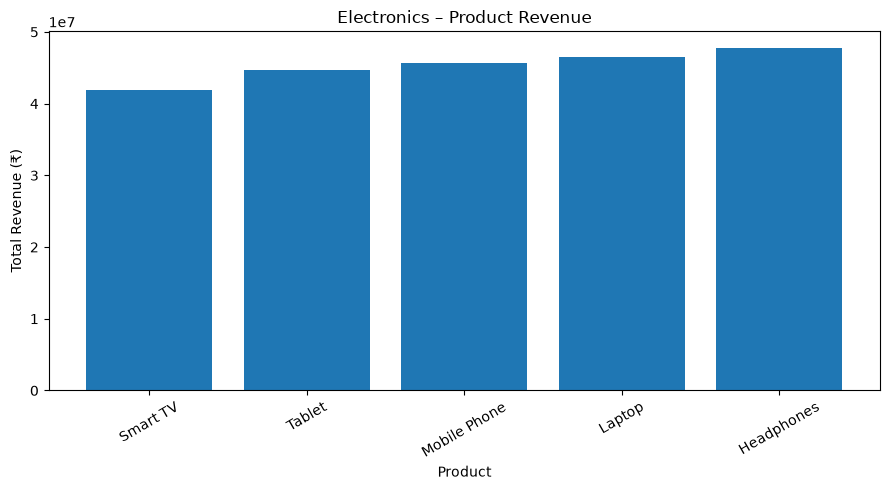

In [54]:
plt.figure(figsize=(9, 5))

plt.bar(
    electronics_products["product_name"],
    electronics_products["revenue"]
)

plt.title("Electronics – Product Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

### Business Interpretation

The product-level analysis shows which products contribute most and least to each category's total revenue.

Electronics requires closer attention because it has the steepest category-level decline from January to June.

Within Electronics, the lowest-revenue products should be discussed with the supplier to understand whether pricing, demand, product positioning, or other factors are affecting performance.

The product results should be considered together with the overall category trend rather than using product revenue alone to make a final decision.

## Step 4 – Discount Effectiveness

We analyze different discount levels to understand whether higher discounts lead to higher average revenue per transaction and higher average units sold.

The discount brackets used are 0%, 5%, 10%, 15%, 20%, and 25%+.

In [55]:
def discount_bracket(x):
    if x == 0:
        return "0%"
    elif x == 5:
        return "5%"
    elif x == 10:
        return "10%"
    elif x == 15:
        return "15%"
    elif x == 20:
        return "20%"
    else:
        return "25%+"

df["discount_bracket"] = df["discount_pct"].apply(discount_bracket)

print(df[["discount_pct", "discount_bracket"]].head(20))

    discount_pct discount_bracket
0              5               5%
1              0               0%
2             10              10%
3              5               5%
4              0               0%
5             20              20%
6              5               5%
7              0               0%
8              0               0%
9             10              10%
10             0               0%
11             5               5%
12            20              20%
13            10              10%
14            10              10%
15             0               0%
16             5               5%
17             0               0%
18            10              10%
19             5               5%


In [56]:
discount_analysis = df.groupby("discount_bracket").agg(
    avg_revenue=("revenue", "mean"),
    avg_units_sold=("units_sold", "mean")
)

discount_order = ["0%", "5%", "10%", "15%", "20%", "25%+"]

discount_analysis = discount_analysis.reindex(discount_order)

print(discount_analysis)

                  avg_revenue  avg_units_sold
discount_bracket                             
0%                4685.654340        2.586018
5%                4303.730312        2.591882
10%               4005.545405        2.566401
15%               4069.164408        2.595140
20%               3631.727433        2.581493
25%+                      NaN             NaN


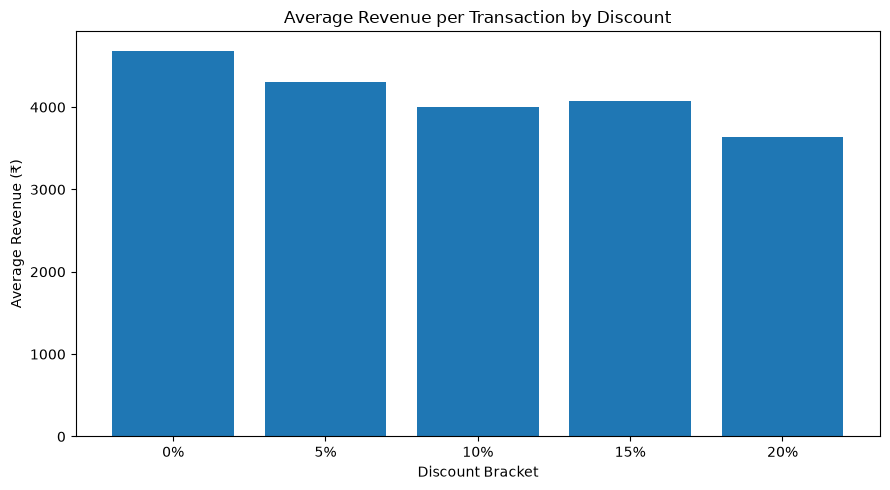

In [57]:
plt.figure(figsize=(9, 5))

plt.bar(
    discount_analysis.index,
    discount_analysis["avg_revenue"]
)

plt.title("Average Revenue per Transaction by Discount")
plt.xlabel("Discount Bracket")
plt.ylabel("Average Revenue (₹)")

plt.tight_layout()
plt.show()

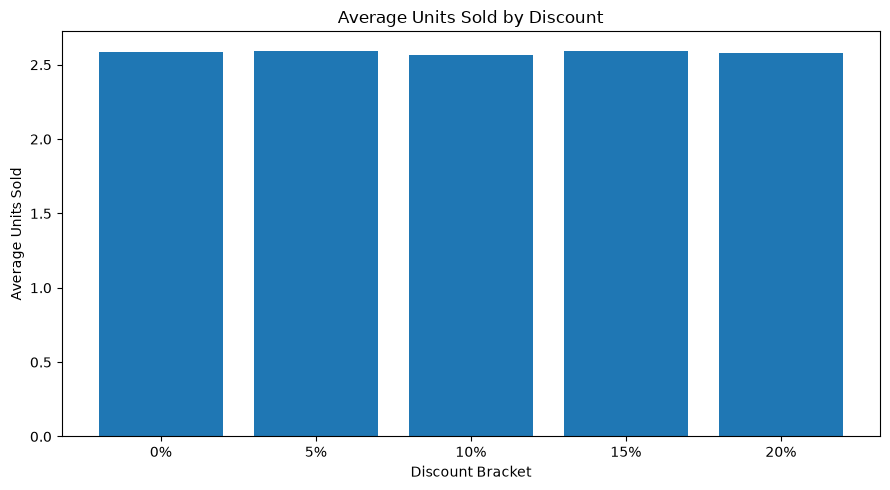

In [58]:
plt.figure(figsize=(9, 5))

plt.bar(
    discount_analysis.index,
    discount_analysis["avg_units_sold"]
)

plt.title("Average Units Sold by Discount")
plt.xlabel("Discount Bracket")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

In [59]:
valid_revenue = discount_analysis["avg_revenue"].dropna()

print("Highest Average Revenue Discount Bracket:")
print(valid_revenue.idxmax())

print("\nHighest Average Revenue:")
print(valid_revenue.max())

Highest Average Revenue Discount Bracket:
0%

Highest Average Revenue:
4685.6543396331135


In [60]:
valid_units = discount_analysis["avg_units_sold"].dropna()

print("Highest Average Units Sold Discount Bracket:")
print(valid_units.idxmax())

print("\nHighest Average Units Sold:")
print(valid_units.max())

Highest Average Units Sold Discount Bracket:
15%

Highest Average Units Sold:
2.5951403435274405


### Business Interpretation

The discount analysis compares average revenue per transaction and average units sold across different discount levels.

The results should be used to determine whether higher discounts are associated with stronger transaction performance.

In this dataset, there are no transactions above a 20% discount, so the 25%+ bracket has no observations.

Discount effectiveness should not be judged only from revenue. Product cost and gross-margin data would also be required to understand the actual profitability impact of discounts.

## Step 5 – Sales Patterns

In this step, we analyze sales patterns based on the day of the week and month.

This helps the Category Manager understand when customer activity and revenue are higher or lower.

In [61]:
df["day_of_week"] = df["date"].dt.day_name()

print(df[["date", "day_of_week"]].head(10))

        date day_of_week
0 2026-01-01    Thursday
1 2026-01-01    Thursday
2 2026-01-01    Thursday
3 2026-01-01    Thursday
4 2026-01-01    Thursday
5 2026-01-01    Thursday
6 2026-01-01    Thursday
7 2026-01-01    Thursday
8 2026-01-01    Thursday
9 2026-01-01    Thursday


In [62]:
day_revenue = df.groupby(
    "day_of_week"
)["revenue"].mean()

days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_revenue = day_revenue.reindex(days)

print(day_revenue)

day_of_week
Monday       4131.380009
Tuesday      4017.706483
Wednesday    4289.790612
Thursday     4255.307474
Friday       4255.921458
Saturday     4420.019374
Sunday       4352.211678
Name: revenue, dtype: float64


In [63]:
print("Highest Average Revenue Day:")
print(day_revenue.idxmax())

print("\nHighest Average Revenue:")
print(day_revenue.max())

print("\nLowest Average Revenue Day:")
print(day_revenue.idxmin())

print("\nLowest Average Revenue:")
print(day_revenue.min())

Highest Average Revenue Day:
Saturday

Highest Average Revenue:
4420.019374246152

Lowest Average Revenue Day:
Tuesday

Lowest Average Revenue:
4017.706483111412


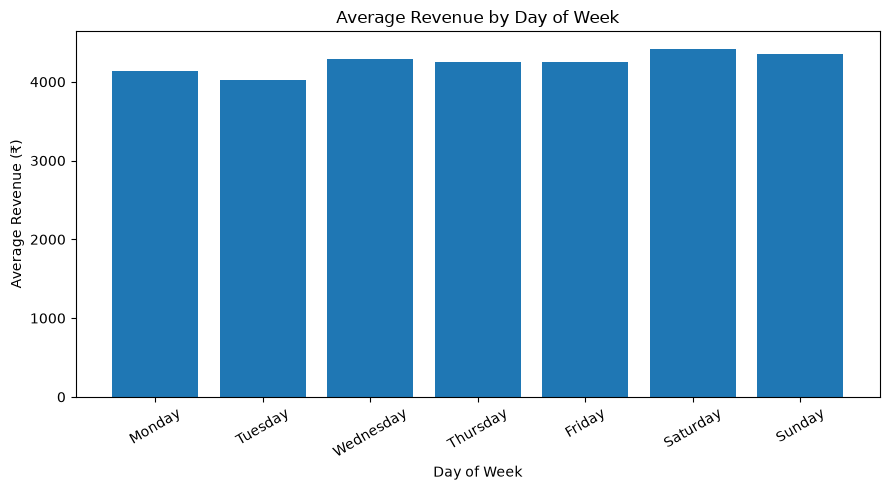

In [64]:
plt.figure(figsize=(9, 5))

plt.bar(
    day_revenue.index,
    day_revenue.values
)

plt.title("Average Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Revenue (₹)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [65]:
monthly_revenue = df.groupby(
    "month"
)["revenue"].sum()

print(monthly_revenue)

month
2026-01    84768131.10
2026-02    73833666.23
2026-03    80689884.84
2026-04    75670487.12
2026-05    75559873.38
2026-06    69282134.11
Name: revenue, dtype: float64


In [66]:
print("Highest Revenue Month:")
print(monthly_revenue.idxmax())

print("\nHighest Monthly Revenue:")
print(monthly_revenue.max())

print("\nLowest Revenue Month:")
print(monthly_revenue.idxmin())

print("\nLowest Monthly Revenue:")
print(monthly_revenue.min())

Highest Revenue Month:
2026-01

Highest Monthly Revenue:
84768131.1

Lowest Revenue Month:
2026-06

Lowest Monthly Revenue:
69282134.11


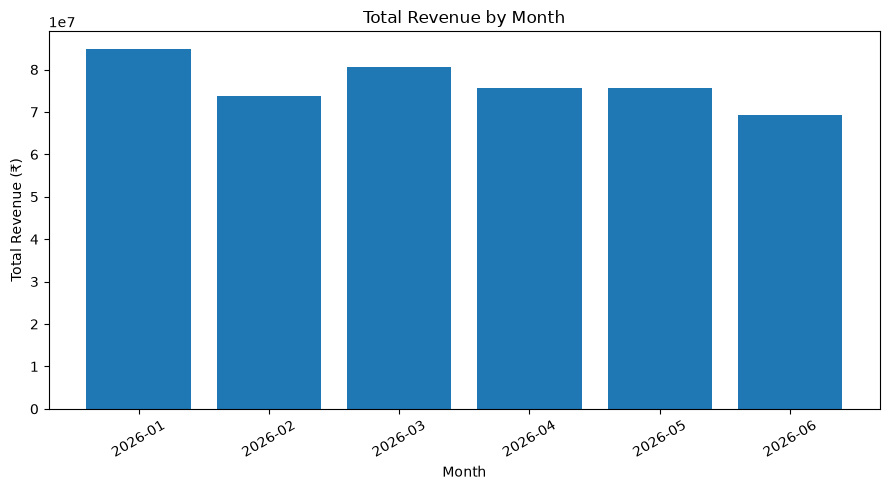

In [67]:
plt.figure(figsize=(9, 5))

plt.bar(
    monthly_revenue.index,
    monthly_revenue.values
)

plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

### Business Interpretation

The day-of-week analysis shows which days have higher or lower average transaction revenue.

The monthly analysis shows how total revenue changes across the six-month period.

These patterns can help the Category Manager plan promotions, staffing, inventory availability, and supplier discussions around periods of stronger or weaker sales activity.

The results should be interpreted together with category and product trends rather than using day or month patterns alone.

# Step 6 – Category Manager Briefing

## Key Business Findings

The analysis provides insights into category trends, product performance, discount effectiveness, and sales patterns.

The following findings can support the Category Manager during the supplier review meeting.

In [68]:
final_findings = {
    "Metric": [
        "Highest Growth Category",
        "Steepest Decline Category",
        "Lowest Revenue Electronics Product",
        "Highest Average Units Sold Discount",
        "Highest Revenue Day"
    ],
    "Result": [
        change.idxmax(),
        change.idxmin(),
        electronics_products.iloc[0]["product_name"],
        valid_units.idxmax(),
        day_revenue.idxmax()
    ]
}

final_findings_df = pd.DataFrame(final_findings)

final_findings_df

,Metric,Result
0,Highest Growth Category,Apparel
1,Steepest Decline Category,Electronics
2,Lowest Revenue Electronics Product,Smart TV
3,Highest Average Units Sold Discount,15%
4,Highest Revenue Day,Saturday


In [69]:
print("Highest Growth Category:", change.idxmax())
print("Growth:", round(change.max(), 2), "%")

print("\nSteepest Decline Category:", change.idxmin())
print("Decline:", round(change.min(), 2), "%")

print("\nLowest Electronics Product:")
print(electronics_products.iloc[0]["product_name"])
print("Revenue: ₹", round(electronics_products.iloc[0]["revenue"], 2))

print("\nHighest Average Units Sold Discount:")
print(valid_units.idxmax())
print("Average Units:", round(valid_units.max(), 2))

print("\nHighest Revenue Day:")
print(day_revenue.idxmax())
print("Average Revenue: ₹", round(day_revenue.max(), 2))

print("\nHighest Revenue Month:")
print(monthly_revenue.idxmax())
print("Revenue: ₹", round(monthly_revenue.max(), 2))

Highest Growth Category: Apparel
Growth: 34.1 %

Steepest Decline Category: Electronics
Decline: -35.02 %

Lowest Electronics Product:
Smart TV
Revenue: ₹ 41882166.21

Highest Average Units Sold Discount:
15%
Average Units: 2.6

Highest Revenue Day:
Saturday
Average Revenue: ₹ 4420.02

Highest Revenue Month:
2026-01
Revenue: ₹ 84768131.1


## Category Manager Briefing

### 1. Category Showing Strong Growth

Apparel showed the strongest January-to-June revenue growth in the dataset.

This indicates that Apparel should receive attention when planning future category activities.

### 2. Category Requiring Supplier Review

Electronics showed the steepest January-to-June revenue decline.

The Category Manager should discuss this decline with the Electronics supplier and investigate the reasons behind the weaker performance.

### 3. Product Requiring Attention

Within Electronics, Smart TV had the lowest total revenue among the Electronics products.

The supplier discussion should examine possible factors such as pricing, demand, product positioning, and promotion strategy.

### 4. Discount Finding

The discount analysis shows differences in average revenue and units sold across discount levels.

The 15% discount bracket had the highest average units sold in this dataset.

However, discount effectiveness should not be judged only from revenue or units sold.

### 5. Additional Data Required

Product cost and gross-margin data are required before making a final profitability or investment decision.

### 6. Overall Conclusion

EDA helped convert raw retail transaction data into useful business insights.

The analysis identified category trends, product-level performance, discount patterns, and sales timing patterns that can support the Category Manager's supplier review.

In [70]:
print("========== FINAL PROJECT SUMMARY ==========")

print("\n1. Dataset")
print("Transactions:", len(df))
print("Products:", df["product_name"].nunique())
print("Categories:", df["category"].nunique())

print("\n2. Category Trend")
print("Highest Growth:", change.idxmax(), round(change.max(), 2), "%")
print("Steepest Decline:", change.idxmin(), round(change.min(), 2), "%")

print("\n3. Electronics")
print("Lowest Revenue Product:",
      electronics_products.iloc[0]["product_name"])
print("Revenue: ₹",
      round(electronics_products.iloc[0]["revenue"], 2))

print("\n4. Discount")
print("Highest Units Sold Bracket:", valid_units.idxmax())
print("Average Units Sold:",
      round(valid_units.max(), 2))

print("\n5. Sales Pattern")
print("Highest Revenue Day:", day_revenue.idxmax())
print("Highest Revenue Month:", monthly_revenue.idxmax())

print("\n========== PROJECT COMPLETED ==========")

========== FINAL PROJECT SUMMARY ==========

1. Dataset
Transactions: 107836
Products: 25
Categories: 5

2. Category Trend
Highest Growth: Apparel 34.1 %
Steepest Decline: Electronics -35.02 %

3. Electronics
Lowest Revenue Product: Smart TV
Revenue: ₹ 41882166.21

4. Discount
Highest Units Sold Bracket: 15%
Average Units Sold: 2.6

5. Sales Pattern
Highest Revenue Day: Saturday
Highest Revenue Month: 2026-01

========== PROJECT COMPLETED ==========
